In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import jensenshannon
import torch
import torch.nn as nn
import random

# prepare the labels y

In [5]:
dataset = pd.read_parquet('../kinpfn_testing_set/parquet_parsing/test_val_dataset.parquet')

In [6]:
arr_fpts = np.array([row for row in dataset['fpts']])

In [7]:
arr_fpts.shape

(2654, 1000)

In [8]:
np.min(arr_fpts)

np.float64(0.0)

In [9]:
np.max(arr_fpts)

np.float64(297458098.413)

In [10]:
np.where(arr_fpts == 0)

(array([ 251,  258,  274,  274,  274,  274,  274,  274,  274,  333,  349,
         349,  453,  459,  464,  465,  465,  465,  465,  478,  480,  480,
         482,  484,  484,  484,  484,  491,  491,  491,  491,  527, 1373,
        1441, 1490, 1490, 1490, 1497, 1510, 1510, 1510, 1514, 1514, 1531,
        1897, 2157, 2167, 2167, 2179, 2183, 2201, 2220, 2235, 2245, 2248,
        2253, 2253, 2255, 2256, 2256, 2257, 2267, 2282, 2282, 2282, 2295,
        2296, 2296, 2298, 2298, 2316, 2316, 2322, 2328, 2328, 2328, 2355,
        2355, 2361, 2361, 2361, 2381, 2381, 2390, 2446]),
 array([ 81, 180, 186, 211, 222, 408, 472, 555, 965, 153, 412, 864, 560,
         11, 389,  66, 250, 625, 641, 903, 420, 612, 230, 276, 306, 452,
        783,  40, 141, 432, 792, 643, 805, 460, 148, 175, 728, 730, 208,
        270, 368, 777, 928, 529, 320, 454, 468, 774, 626,  53, 920, 921,
        808, 525, 892, 135, 360, 589, 617, 702, 865, 711,  70, 601, 719,
        792, 226, 597, 553, 751,   8, 332, 531, 396, 552, 6

In [11]:
where_arr_fpts_nonzero = np.where(arr_fpts != 0)
arr_logfpts = np.log(arr_fpts[where_arr_fpts_nonzero])

In [12]:
np.min(arr_logfpts)

np.float64(-6.907755278982137)

In [13]:
np.max(arr_logfpts)

np.float64(19.510783927359686)

In [14]:
arr_logfpts.shape

(2653915,)

In [15]:
n_bins = 50

binedges_logfpt = np.linspace(np.min(arr_logfpts), np.max(arr_logfpts), n_bins+1)

In [16]:
arr_hist_logfpts = np.zeros((dataset.shape[0], n_bins))
for index, row in dataset.iterrows():
    fpts = row['fpts']
    where_fpts_nonzero = np.where(fpts != 0)
    logfpts = np.log(fpts[where_fpts_nonzero])
    hist_logfpts, _ = np.histogram(logfpts, binedges_logfpt, density=True)
    hist_logfpts /= np.sum(hist_logfpts) # normalize so that values add to 1; this does not reflect the probability density
    arr_hist_logfpts[index] = hist_logfpts


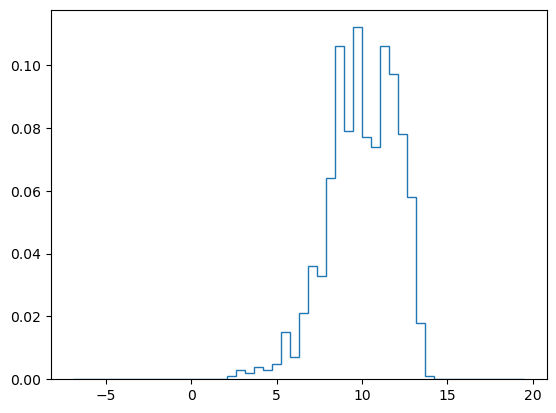

In [17]:
plt.stairs(arr_hist_logfpts[67], binedges_logfpt)

In [18]:
y = arr_hist_logfpts

In [19]:
np.sum(y, axis=1)

array([1., 1., 1., ..., 1., 1., 1.], shape=(2654,))

In [20]:
print(y.shape)

(2654, 50)


# prepare the features X

In [21]:
print(dataset.columns)

Index(['filepath', 'sequence', 'length', 'mfe_from_file',
       'dot_bracket_from_file', 'fpts', 'gc_content', 'freq_A', 'freq_U',
       'freq_G',
       ...
       'min_11_tree_dist', 'min_12_tree_dist', 'min_13_tree_dist',
       'min_14_tree_dist', 'min_15_tree_dist', 'min_16_tree_dist',
       'min_17_tree_dist', 'min_18_tree_dist', 'min_19_tree_dist',
       'min_20_tree_dist'],
      dtype='object', length=110)


In [22]:
X = dataset.drop(columns=['filepath', 'sequence', 'dot_bracket_from_file', 'fpts', 'mfe_structure', 'mfe'])
for i in range(1, 21):
    X = X.drop(columns=['min_'+str(i)+'_structure'])
    X = X.drop(columns=['min_'+str(i)+'_energy'])
    X = X.drop(columns=['min_'+str(i)+'_bp_dist'])
    X = X.drop(columns=['min_'+str(i)+'_tree_dist'])

In [23]:
X.shape

(2654, 24)

In [24]:
with pd.option_context('display.max_rows', None):
    print(X.iloc[0])

length            100.000000
mfe_from_file     -29.300000
gc_content          0.530000
freq_A              0.270000
freq_U              0.200000
freq_G              0.270000
freq_C              0.260000
freq_AA             0.070707
freq_AU             0.030303
freq_AG             0.101010
freq_AC             0.070707
freq_UA             0.040404
freq_UU             0.060606
freq_UG             0.050505
freq_UC             0.050505
freq_GA             0.070707
freq_GU             0.060606
freq_GG             0.060606
freq_GC             0.080808
freq_CA             0.090909
freq_CU             0.040404
freq_CG             0.060606
freq_CC             0.060606
n_local_minima     26.000000
Name: 0, dtype: float64


In [25]:
X.shape

(2654, 24)

In [26]:
X = np.array(X)

In [27]:
X.shape

(2654, 24)

In [28]:
y.shape

(2654, 50)

# train the model

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [31]:
class GLM(nn.Module):
    def __init__(self, input_dim, n_bins=50):
        super().__init__()
        self.linear = nn.Linear(input_dim, n_bins)
    
    def forward(self, x):
        return self.linear(x)  # return logits; apply log_softmax in loss

In [32]:
X_train.shape

(1916, 24)

In [33]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [34]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

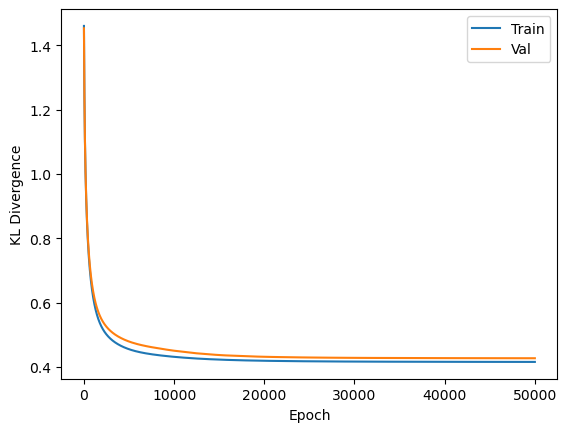

In [35]:
set_seed(42)

model = GLM(input_dim=X_train.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.KLDivLoss(reduction='batchmean')  # soft targets

train_losses, val_losses = [], []

for epoch in range(50000):
    model.train()
    log_probs = torch.log_softmax(model(X_train_t), dim=-1)
    loss = loss_fn(log_probs, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        log_probs_val = torch.log_softmax(model(X_val_t), dim=-1)
        val_loss = loss_fn(log_probs_val, y_val_t)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.legend()
plt.show()

In [36]:
model.eval()
with torch.no_grad():
    log_probs = torch.log_softmax(model(X_val_t), dim=-1)
    val_loss = loss_fn(log_probs, y_val_t)
    print(f"Val KL divergence: {val_loss.item():.4f}")

Val KL divergence: 0.4271


In [37]:
model.eval()
with torch.no_grad():
    probs = torch.softmax(model(X_val_t), dim=-1).numpy()

js_scores = [jensenshannon(y_val[i], probs[i]) for i in range(len(y_val))]
print(f"Mean JS divergence: {np.mean(js_scores):.4f}")
print(f"Median JS divergence: {np.median(js_scores):.4f}")

Mean JS divergence: 0.3166
Median JS divergence: 0.3131


1.0
1.0000001
1.0
1.0
1.0000000000000002
0.9999999
1.0
1.0000001
0.9999999999999999
0.99999994
1.0
1.0


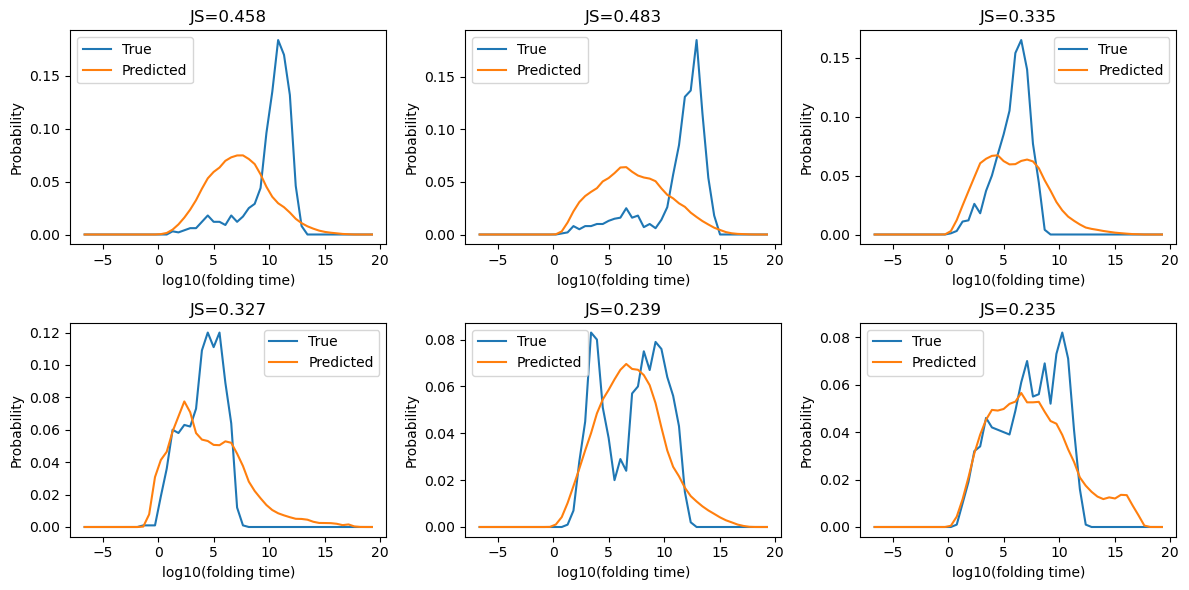

In [38]:
bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.plot(bin_centers, y_val[i], label='True')
    print(np.sum(y_val[i]))
    ax.plot(bin_centers, probs[i], label='Predicted')
    print(np.sum(probs[i]))
    ax.set_title(f"JS={js_scores[i]:.3f}")
    ax.set_xlabel('log10(folding time)')
    ax.set_ylabel('Probability')
    ax.legend()
plt.tight_layout()
plt.show()